# Clinico-Transcriptomic Discovery of Prognostic Biomarkers and Functional Hallmarks in TCGA Breast Cancer Using Python
---
   ## Notebook 5: Survival Analysis and Clinical Validation of Candidate Biomarkers

### 1. Biological Motivation
The preceding analyses identified a specific transcriptional program associated with poor survival in breast cancer patients. While differential expression analysis successfully highlighted genes that distinguish patients who survived from those who died, statistical dysregulation alone does not inherently establish a direct link to clinical prognosis; some strongly altered genes may simply reflect downstream consequences of disease progression rather than driving differences in patient outcomes.

The objective of this notebook is to validate the clinical relevance of these candidate biomarkers by transitioning from static differential expression to dynamic survival modelling, determining whether individual gene expression levels are directly associated with overall patient survival.

To achieve this, two complementary survival analysis strategies are employed:

* Kaplan-Meier Survival Analysis: Used to stratify patients into high- and low-expression groups and compare their survival trajectories over time, with statistical differences evaluated via the log-rank test.

* Cox Proportional Hazards Regression: Employed to fit multivariable models that quantify hazard ratios, assessing the independent contribution of gene expression to mortality risk both in isolation and after adjusting for major clinical treatment variables.

This notebook addresses the following biological and clinical questions:

> Are the expression levels of the identified candidate biomarkers significantly associated with overall patient survival?

> Do these candidate biomarkers retain independent prognostic value when adjusted for standard treatment variables?

> How does the predictive performance of a gene-only survival model compare to a treatment-adjusted model?

> Can these molecular signatures provide a reliable bridge between transcriptomic discovery and clinical interpretation?

### 2. Import Required Libraries


In [1]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

from lifelines import CoxPHFitter

### 3. Load Processed Expression and Clinical Data


In [2]:
counts_log = pd.read_csv("../data/processed/brca_counts_normalized_log.csv", index_col=0)
clinical = pd.read_csv("../data/processed/brca_clinical_cleaned.csv", index_col=0)
dgea_results = pd.read_csv("../results/tables/brca_dgea_master_results.csv")

### 4. Annotate the Expression Matrix with Gene Symbols

In [3]:
if "gene_id" in dgea_results.columns:
    dgea_lookup = dgea_results.set_index("gene_id")
else:
    dgea_lookup = dgea_results.copy()

counts_log_named = counts_log.merge(dgea_lookup[["gene_name"]], left_index=True, right_index=True, how="inner")
counts_log_named = counts_log_named.drop_duplicates(subset=["gene_name"]).set_index("gene_name")

print(f"Survival framework initialized. Evaluated patient matrix cohort size: {clinical.shape[0]}")

Survival framework initialized. Evaluated patient matrix cohort size: 1019


### 5. Kaplan-Meier Survival Analysis

Kaplan-Meier analysis provides a non-parametric estimate of survival probability over time and is widely used to compare prognosis between patient groups.

For each candidate biomarker, patients are divided into high- and low-expression groups using the median expression value as the cutoff. Differences between survival curves are evaluated using the log-rank test.

This approach provides an intuitive visual assessment of whether elevated gene expression is associated with poorer clinical outcome.

The following function performs the complete survival analysis workflow:

* extracts gene expression
* merges expression with survival metadata
* performs median dichotomization
* computes the log-rank test
* plots Kaplan-Meier survival curves
* saves publication-quality figures

In [4]:
def plot_km_survival(gene_symbol, clinical_df, expression_df):
    """Splits patients by median gene expression and plots Kaplan-Meier survival curves."""
    if gene_symbol not in expression_df.index:
        print(f"Error: {gene_symbol} not found in expression matrix indices.")
        return

    # 1. Extract expression values for the specific gene across all patients
    gene_expr = expression_df.loc[gene_symbol]

    # 2. Merge expression with clinical tracking framework
    survival_df = clinical_df[["time", "event"]].merge(
        gene_expr, left_index=True, right_index=True, how="inner"
    )
    survival_df = survival_df.dropna()

    # 3. Perform Median Split
    median_val = survival_df[gene_symbol].median()
    high_group = survival_df[survival_df[gene_symbol] > median_val]
    low_group = survival_df[survival_df[gene_symbol] <= median_val]

    if high_group.empty or low_group.empty:
        print(f"Skipping {gene_symbol}: Insufficient group sizing.")
        return

    # 4. Run Log-Rank Statistical Test
    results = logrank_test(
        high_group["time"],
        low_group["time"],
        event_observed_A=high_group["event"],
        event_observed_B=low_group["event"],
    )
    p_value = results.p_value

    # 5. Initialize KaplanMeier Fitter
    kmf_high = KaplanMeierFitter()
    kmf_low = KaplanMeierFitter()

    plt.figure(figsize=(9, 6))

    # Fit and plot High Expression group
    kmf_high.fit(
        high_group["time"],
        event_observed=high_group["event"],
        label=f"High {gene_symbol} (n={high_group.shape[0]})",
    )
    kmf_high.plot_survival_function(color="#d95f02", linewidth=2.5, ci_show=False)

    # Fit and plot Low Expression group
    kmf_low.fit(
        low_group["time"],
        event_observed=low_group["event"],
        label=f"Low {gene_symbol} (n={low_group.shape[0]})",
    )
    kmf_low.plot_survival_function(color="#1f78b4", linewidth=2.5, ci_show=False)

    # Styling elements
    plt.title(
        f"Kaplan-Meier Survival Analysis for {gene_symbol}\nLog-Rank p-value: {p_value:.4e}",
        fontsize=13,
        fontweight="bold",
    )
    plt.xlabel("Timeline Survival Duration (Days)", fontsize=11)
    plt.ylabel("Overall Survival Probability", fontsize=11)
    plt.grid(alpha=0.2)
    plt.xlim(0, survival_df["time"].max())
    plt.ylim(0, 1.05)
    plt.legend(loc="lower left", frameon=True)

    # Save visualization to results directory automatically
    plt.savefig(
        f"../results/figures/survival_plots/{gene_symbol}_km_curve.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    print(f"Analysis for {gene_symbol} finalized. Log-Rank p-value: {p_value:.6f}")

### 6. Survival Analysis of Candidate Biomarkers

Five representative genes were selected based on previous differential expression and pathway enrichment analyses.

* **PLK1** – master regulator of mitosis
* **MAD2L1** – spindle assembly checkpoint protein
* **TRIM67** – ubiquitin ligase and highly upregulated candidate biomarker
* **NOS1** – metabolic signalling enzyme
* **ALB** – lineage-associated marker

Each gene was evaluated independently using Kaplan-Meier survival analysis.



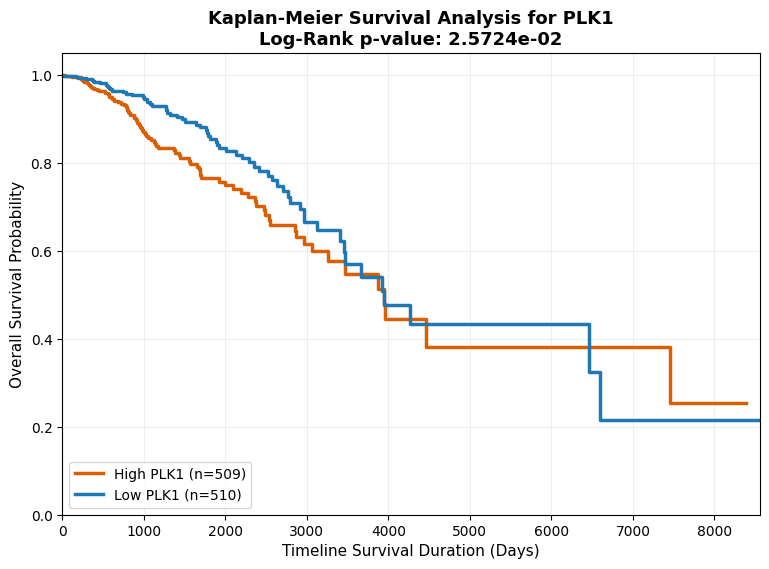

Analysis for PLK1 finalized. Log-Rank p-value: 0.025724


In [5]:
plot_km_survival("PLK1", clinical, counts_log_named)

#### 6.1 PLK1

PLK1 demonstrated a statistically significant association with overall survival (Log-rank **p = 0.0257**).

Patients exhibiting high PLK1 expression experienced consistently lower survival probabilities throughout the first decade of follow-up compared with patients expressing lower levels of PLK1. The separation between survival curves persisted across most of the observation period, indicating that increased activation of mitotic machinery is associated with poorer prognosis.

Although the curves converge during the extreme tail of follow-up, this behaviour is expected in long-term survival studies due to the progressively diminishing number of patients remaining at risk. Consequently, late-stage curve crossings should not be interpreted as evidence against the overall survival difference observed during the clinically relevant portion of follow-up.

Overall, these findings support PLK1 as a clinically relevant proliferation-associated biomarker.


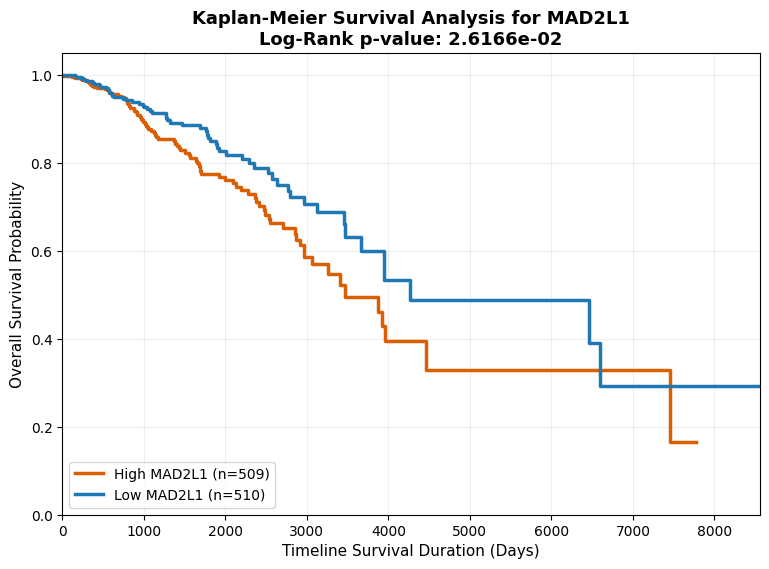

Analysis for MAD2L1 finalized. Log-Rank p-value: 0.026166


In [6]:
plot_km_survival("MAD2L1", clinical, counts_log_named)

#### 6.2 MAD2L1

MAD2L1 also exhibited significant survival stratification (Log-rank **p = 0.0262**).

Patients with elevated MAD2L1 expression demonstrated reduced overall survival across most of the study duration. As observed for PLK1, late-stage fluctuations occurred only after the number of patients under observation had substantially declined, suggesting that these crossings represent statistical artefacts rather than genuine biological reversals.

Given the central role of MAD2L1 in spindle checkpoint regulation, these findings further support the importance of dysregulated cell-cycle progression in aggressive breast cancer.



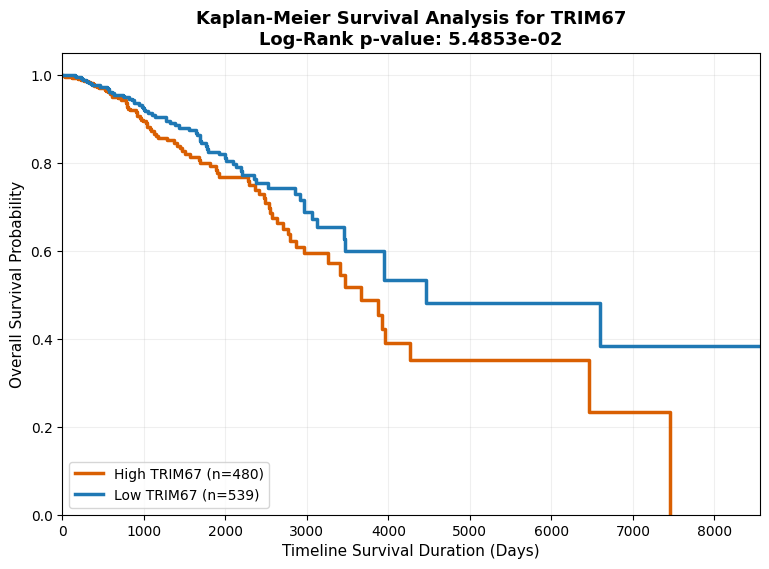

Analysis for TRIM67 finalized. Log-Rank p-value: 0.054853


In [7]:
plot_km_survival("TRIM67", clinical, counts_log_named)

#### 6.3 TRIM67

TRIM67 showed a clear visual separation between survival curves, with patients exhibiting higher expression generally experiencing poorer survival.

However, the log-rank test narrowly missed conventional statistical significance (Log-rank **p = 0.0549**). This result should therefore be interpreted as evidence of a trend toward adverse prognosis rather than definitive prognostic significance.

Considering that TRIM67 emerged as one of the most strongly upregulated genes during differential expression analysis, its borderline survival association suggests that its biological role may depend on broader molecular or clinical context rather than acting as an isolated prognostic factor.



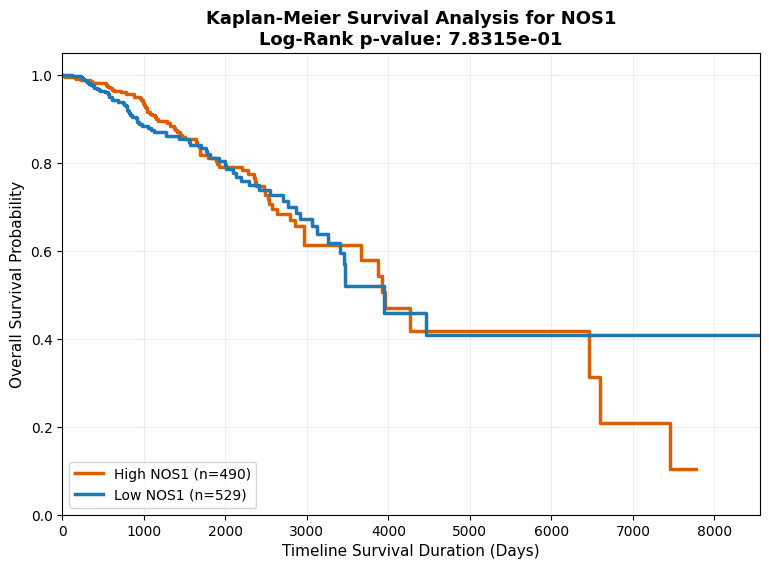

Analysis for NOS1 finalized. Log-Rank p-value: 0.783152


In [8]:
plot_km_survival("NOS1", clinical, counts_log_named)

#### 6.4 NOS1

NOS1 expression showed extensive overlap between high- and low-expression groups throughout the observation period.

The log-rank test indicated no statistically significant difference in survival (Log-rank **p = 0.7832**), suggesting that although NOS1 is transcriptionally dysregulated, its expression alone does not effectively stratify patient survival.


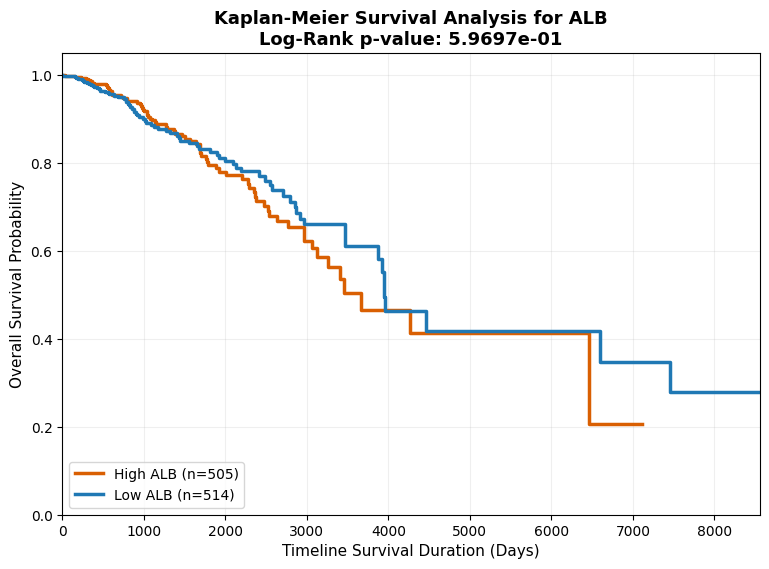

Analysis for ALB finalized. Log-Rank p-value: 0.596969


In [9]:
plot_km_survival("ALB", clinical, counts_log_named)

#### 6.5 ALB

Similarly, ALB expression was not significantly associated with overall survival (Log-rank **p = 0.5970**).

Despite modest fluctuations in survival probability, both expression groups followed broadly similar trajectories throughout follow-up, indicating limited prognostic utility when considered independently.


#### Interpretation of Kaplan-Meier Results:

A notable observation is that genes exhibiting the largest transcriptional changes were not necessarily those providing the strongest survival discrimination.

PLK1 and MAD2L1, both central regulators of mitosis, demonstrated statistically significant survival differences despite exhibiting more modest fold changes than certain metabolic or lineage-associated genes. Conversely, TRIM67, NOS1, and ALB, although highly dysregulated, displayed weaker or non-significant survival associations.

This distinction highlights an important principle in cancer transcriptomics. Differential expression identifies genes associated with disease state, whereas survival analysis evaluates whether variation in expression corresponds to differences in patient outcome. These objectives are related but fundamentally distinct, and not all biologically altered genes function as independent prognostic biomarkers.


### 7. Multivariable Cox Proportional Hazards Regression - Gene-Only Survival Model

To quantify the independent contribution of candidate biomarkers, a multivariable Cox proportional hazards model was constructed using expression levels of the five selected genes.


In [10]:
genes_of_interest = ["PLK1", "MAD2L1", "TRIM67", "NOS1", "ALB"]
target_expr = counts_log_named.loc[genes_of_interest].T

cox_data = target_expr.merge(
    clinical[["time", "event"]], 
    left_index=True, 
    right_index=True, 
    how="inner"
)

cox_data = cox_data.dropna()

print(f"Matrix built for Cox Regression. Profile size: {cox_data.shape[0]} patients")

cph = CoxPHFitter()
cph.fit(cox_data, duration_col="time", event_col="event")

cph.print_summary()

Matrix built for Cox Regression. Profile size: 1019 patients


<lifelines.CoxPHFitter: fitted with 1019 total observations, 870 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1019
number of events observed = 149
   partial log-likelihood = -830.82
         time fit was run = 2026-06-18 23:25:20 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
PLK1       0.17      1.18      0.11           -0.05            0.39                0.95                1.48
MAD2L1    -0.09      0.92      0.13           -0.34            0.17                0.71                1.19
TRIM67     0.13      1.14      0.05            0.04            0.22                1.04                1.25
NOS1       0.04      1.04      0.05           -0.06            0.14                0.95                1.15
ALB        0.03      1.03      0.03           -0.03            0.08                0.97                1.09

           cmp to     z    p  -log2(p)
covariate                             
PLK1         0.00  1.50 0.13      2.90
MAD2L1       0.00 -0.65 0.51      0.96
TRIM67       0.00  2.74 0.01      7.35
NOS1         0.00  0.84 0.40      1.32
ALB          0.00  0.86 0.39      1.36
---
Concordance = 0.58
Partial AIC = 1671.63
log-likelihood ratio test = 13.52 on 5 df
-log2(p) of ll-ratio test = 5.72

#### Interpretation:

Among the five biomarkers, **TRIM67** emerged as the only statistically significant predictor of mortality.

A one-unit increase in TRIM67 expression was associated with an estimated **14% increase in the hazard of death (HR = 1.14, p = 0.01)** after accounting for the remaining genes included in the model.

PLK1 and MAD2L1 did not retain statistical significance despite demonstrating significant Kaplan-Meier survival differences. This reduction in significance is likely attributable to multicollinearity, as both genes participate in the same mitotic regulatory network and therefore share substantial biological information.

Overall model discrimination was modest (Concordance Index = **0.58**), indicating that gene expression alone captures only part of the variability in patient survival.


### 8. Treatment-Adjusted Cox Regression

Patient survival is influenced not only by tumour biology but also by therapeutic intervention.

To evaluate whether molecular biomarkers retain independent prognostic value after accounting for treatment, a second Cox regression model incorporated clinical variables representing surgery, chemotherapy, and radiotherapy.

A mild ridge penalty was applied to improve numerical stability and reduce coefficient inflation.


In [11]:
genes_of_interest = ["PLK1", "MAD2L1", "TRIM67", "NOS1", "ALB"]
target_expr = counts_log_named.loc[genes_of_interest].T

treatment_cols = ["had_surgery", "had_chemo", "had_radiation"]
survival_cols = ["time", "event"]

clinical_subset = clinical[survival_cols + treatment_cols].copy()

cox_matrix = target_expr.merge(clinical_subset, left_index=True, right_index=True, how="inner")
cox_matrix = cox_matrix.dropna()

print(f"Dataset compiled for treatment-adjusted Cox modeling.")
print(f"Total patient records: {cox_matrix.shape[0]} samples\n")

cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_matrix, duration_col="time", event_col="event")

cph.print_summary()

Dataset compiled for treatment-adjusted Cox modeling.
Total patient records: 1019 samples



<lifelines.CoxPHFitter: fitted with 1019 total observations, 870 right-censored observations>
             duration col = 'time'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 1019
number of events observed = 149
   partial log-likelihood = -788.81
         time fit was run = 2026-06-18 23:25:22 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
PLK1           0.08      1.08      0.05           -0.02            0.18                0.98                1.20
MAD2L1         0.02      1.02      0.06           -0.10            0.15                0.91                1.16
TRIM67         0.05      1.05      0.04           -0.02            0.12                0.98                1.13
NOS1           0.01      1.01      0.04           -0.06            0.08                0.94                1.09
ALB            0.01      1.01      0.02           -0.03            0.05                0.97                1.05
had_surgery   -2.09      0.12      0.46           -3.00           -1.18                0.05                0.31
had_chemo      0.59      1.80      0.15            0.30            0.88                1.35                2.40
had_radiation -1.57      0.21      0.18           -1.92           -1.22                0.15                0.29

               cmp to     z      p  -log2(p)
covariate                                   
PLK1             0.00  1.50   0.13      2.92
MAD2L1           0.00  0.37   0.71      0.49
TRIM67           0.00  1.46   0.15      2.78
NOS1             0.00  0.33   0.74      0.43
ALB              0.00  0.32   0.75      0.42
had_surgery      0.00 -4.50 <0.005     17.18
had_chemo        0.00  4.00 <0.005     13.97
had_radiation    0.00 -8.84 <0.005     59.85
---
Concordance = 0.76
Partial AIC = 1593.61
log-likelihood ratio test = 97.54 on 8 df
-log2(p) of ll-ratio test = 56.03

#### Interpretation:

Following adjustment for treatment variables, none of the five molecular biomarkers remained independently significant.

Instead, the strongest predictors of survival were clinical interventions.

Surgical treatment was associated with a substantial reduction in mortality risk (HR = 0.12), while radiotherapy similarly demonstrated a strong protective association (HR = 0.21). Conversely, chemotherapy was associated with increased mortality risk (HR = 1.80).

This latter observation should not be interpreted as evidence that chemotherapy is harmful. Rather, it reflects **confounding by indication**, whereby chemotherapy is preferentially administered to patients presenting with more advanced, aggressive, or metastatic disease. Consequently, chemotherapy functions as a surrogate marker for baseline disease severity within observational clinical datasets.

Importantly, incorporation of treatment variables substantially improved overall predictive performance, increasing the model concordance from **0.58** to **0.76**. This marked improvement demonstrates that integrating molecular biomarkers with clinical information yields considerably stronger survival prediction than either source of information alone.


### Notebook Summary


The survival analyses provide an important extension of the transcriptomic findings generated in previous notebooks.

Genes involved in mitotic regulation, particularly PLK1 and MAD2L1, exhibited significant associations with patient survival, supporting the hypothesis that dysregulated cell-cycle progression contributes directly to adverse clinical outcome.

In contrast, several highly dysregulated genes identified during differential expression analysis did not independently predict survival. This observation suggests that these genes are more likely to reflect downstream consequences of tumour progression or broader biological reprogramming rather than functioning as primary drivers of prognosis.

The treatment-adjusted Cox model further demonstrated that molecular biomarkers operate within a broader clinical context. Once therapeutic interventions were incorporated, the independent effects of individual genes diminished substantially, indicating that aggressive molecular phenotypes are closely linked to treatment selection. Thus, gene expression and clinical management should be considered complementary rather than competing sources of prognostic information.

This notebook translated transcriptomic discoveries into clinically interpretable survival analyses and establish a foundation for subsequent predictive modelling and biomarker development.